In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'../data/raw/pjm_hourly_est.csv')

In [4]:
df

,Datetime,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
0,1998-12-31 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29309.0
1,1998-12-31 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28236.0
2,1998-12-31 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27692.0
3,1998-12-31 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27596.0
4,1998-12-31 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27888.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
178257,2018-01-01 20:00:00,21089.0,13858.0,2732.0,4426.0,18418.0,1962.0,2866.0,9378.0,NaN,44284.0,8401.0,NaN
178258,2018-01-01 21:00:00,20999.0,13758.0,2724.0,4419.0,18567.0,1940.0,2846.0,9255.0,NaN,43751.0,8373.0,NaN
178259,2018-01-01 22:00:00,20820.0,13627.0,2664.0,4355.0,18307.0,1891.0,2883.0,9044.0,NaN,42402.0,8238.0,NaN
178260,2018-01-01 23:00:00,20415.0,13336.0,2614.0,4224.0,17814.0,1820.0,2880.0,8676.0,NaN,40164.0,7958.0,NaN


In [5]:
mask = df['Datetime'].duplicated()
df[mask]

,Datetime,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
139481,2014-11-02 02:00:00,13190.0,9184.0,1634.0,2562.0,8562.0,1240.0,1566.0,6185.0,NaN,23755.0,4571.0,NaN
148265,2015-11-01 02:00:00,10542.0,7923.0,1292.0,2257.0,7345.0,1138.0,944.0,5455.0,NaN,21171.0,3832.0,NaN
156905,2016-11-06 02:00:00,11008.0,8028.0,1364.0,2198.0,8145.0,1107.0,1028.0,5587.0,NaN,21692.0,4089.0,NaN
165713,2017-11-05 02:00:00,10446.0,7878.0,1331.0,1044.0,7468.0,1105.0,900.0,5467.0,NaN,20666.0,3984.0,NaN


In [6]:
df_co = pd.read_csv(r'../data/raw/COMED_hourly.csv')
df_co

,Datetime,COMED_MW
0,2011-12-31 01:00:00,9970.0
1,2011-12-31 02:00:00,9428.0
2,2011-12-31 03:00:00,9059.0
3,2011-12-31 04:00:00,8817.0
4,2011-12-31 05:00:00,8743.0
...,...,...
66492,2018-01-01 20:00:00,13858.0
66493,2018-01-01 21:00:00,13758.0
66494,2018-01-01 22:00:00,13627.0
66495,2018-01-01 23:00:00,13336.0


In [7]:
df_co.isnull().sum()

Datetime    0
COMED_MW    0
dtype: int64

In [8]:
df_co[df_co.duplicated]

,Datetime,COMED_MW


In [9]:
df_co.info()

<class 'pandas.DataFrame'>
RangeIndex: 66497 entries, 0 to 66496
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  66497 non-null  str    
 1   COMED_MW  66497 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1.0 MB


In [10]:
df_co.describe()

,COMED_MW
count,66497.000000
mean,11420.152112
std,2304.139517
min,7237.000000
25%,9780.000000
50%,11152.000000
75%,12510.000000
max,23753.000000


In [11]:
df_ape = pd.read_csv(r"../data/raw/AEP_hourly.csv")
df_ape

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0
...,...,...
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0


In [12]:
df_ape.isnull().sum()#null
df_ape[df_ape.duplicated()]#null

,Datetime,AEP_MW


In [13]:
df_ape.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  str    
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1.9 MB


In [14]:
df_ape.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [15]:
df_day = pd.read_csv(r'../data/raw/DAYTON_hourly.csv')

In [16]:
print(df_day.isnull().sum())
df_day[df_day.duplicated()]

Datetime     0
DAYTON_MW    0
dtype: int64


,Datetime,DAYTON_MW


In [17]:
df_day.describe()

,DAYTON_MW
count,121275.000000
mean,2037.851140
std,393.403153
min,982.000000
25%,1749.000000
50%,2009.000000
75%,2279.000000
max,3746.000000


In [18]:
df_day.info()

<class 'pandas.DataFrame'>
RangeIndex: 121275 entries, 0 to 121274
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Datetime   121275 non-null  str    
 1   DAYTON_MW  121275 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1.9 MB


In [19]:
df_de = pd.read_csv(r'../data/raw/DEOK_hourly.csv')

In [20]:
df_de.isnull().sum()#null
df_de[df_de.duplicated()]

,Datetime,DEOK_MW


In [21]:
df_de.info()

<class 'pandas.DataFrame'>
RangeIndex: 57739 entries, 0 to 57738
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  57739 non-null  str    
 1   DEOK_MW   57739 non-null  float64
dtypes: float64(1), str(1)
memory usage: 902.3 KB


In [22]:
df_de.describe()

,DEOK_MW
count,57739.000000
mean,3105.096486
std,599.859026
min,907.000000
25%,2687.000000
50%,3013.000000
75%,3449.000000
max,5445.000000


In [23]:
df_do = pd.read_csv(r"../data/raw/DOM_hourly.csv")

In [24]:
df_do.isnull().sum()#nll
df_do[df_do.duplicated()]#null

,Datetime,DOM_MW


In [25]:
df_do.info()

<class 'pandas.DataFrame'>
RangeIndex: 116189 entries, 0 to 116188
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  116189 non-null  str    
 1   DOM_MW    116189 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1.8 MB


In [26]:
df_do.describe()

,DOM_MW
count,116189.000000
mean,10949.203625
std,2413.946569
min,1253.000000
25%,9322.000000
50%,10501.000000
75%,12378.000000
max,21651.000000


In [27]:
df_dq = pd.read_csv(r"../data/raw/DUQ_hourly.csv")

In [28]:
df_dq.isnull().sum()#null
df_dq[df_dq.duplicated]#null

,Datetime,DUQ_MW


In [29]:
df_dq.info()

<class 'pandas.DataFrame'>
RangeIndex: 119068 entries, 0 to 119067
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  119068 non-null  str    
 1   DUQ_MW    119068 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1.8 MB


In [30]:
df_dq.describe()

,DUQ_MW
count,119068.000000
mean,1658.820296
std,301.740640
min,1014.000000
25%,1444.000000
50%,1630.000000
75%,1819.000000
max,3054.000000


In [31]:
df_ek = pd.read_csv(r"../data/raw/EKPC_hourly.csv")

In [32]:
df_ek.isnull().sum()#null
df_ek[df_ek.duplicated()]#null

,Datetime,EKPC_MW


In [33]:
df_ek.info()

<class 'pandas.DataFrame'>
RangeIndex: 45334 entries, 0 to 45333
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  45334 non-null  str    
 1   EKPC_MW   45334 non-null  float64
dtypes: float64(1), str(1)
memory usage: 708.5 KB


In [34]:
df_ek.describe()

,EKPC_MW
count,45334.000000
mean,1464.218423
std,378.868404
min,514.000000
25%,1185.000000
50%,1386.000000
75%,1699.000000
max,3490.000000


In [35]:
df_fe = pd.read_csv(r'../data/raw/FE_hourly.csv')

In [36]:
df_fe.isnull().sum()#null
df_fe[df_fe.duplicated()]#null

,Datetime,FE_MW


In [37]:
df_fe.info()
df_fe.describe()

<class 'pandas.DataFrame'>
RangeIndex: 62874 entries, 0 to 62873
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  62874 non-null  str    
 1   FE_MW     62874 non-null  float64
dtypes: float64(1), str(1)
memory usage: 982.5 KB


,FE_MW
count,62874.000000
mean,7792.159064
std,1331.268006
min,0.000000
25%,6807.000000
50%,7700.000000
75%,8556.000000
max,14032.000000


In [38]:
df_ni= pd.read_csv(r'../data/raw/NI_hourly.csv')

In [39]:
df_ni.isnull().sum()#null
df_ni[df_ni.duplicated()]#null

,Datetime,NI_MW


In [40]:
df_fe.info()
df_fe.describe()

<class 'pandas.DataFrame'>
RangeIndex: 62874 entries, 0 to 62873
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  62874 non-null  str    
 1   FE_MW     62874 non-null  float64
dtypes: float64(1), str(1)
memory usage: 982.5 KB


,FE_MW
count,62874.000000
mean,7792.159064
std,1331.268006
min,0.000000
25%,6807.000000
50%,7700.000000
75%,8556.000000
max,14032.000000


In [41]:
df_pj =pd.read_csv(r'../data/raw/PJM_Load_hourly.csv')

In [42]:
df_pj.info()
df_pj.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32896 entries, 0 to 32895
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Datetime     32896 non-null  str    
 1   PJM_Load_MW  32896 non-null  float64
dtypes: float64(1), str(1)
memory usage: 514.1 KB


,PJM_Load_MW
count,32896.000000
mean,29766.427408
std,5849.769954
min,17461.000000
25%,25473.000000
50%,29655.000000
75%,33073.250000
max,54030.000000


In [43]:
df_pj.isnull().sum()#null
df_pj[df_pj.duplicated()]#null

,Datetime,PJM_Load_MW


In [44]:
df_pje =pd.read_csv(r'../data/raw/PJME_hourly.csv')

In [45]:
df_pje.info()
df_pje.describe()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [46]:
df_pje.isnull().sum()#null
df_pje[df_pje.duplicated()]#null

,Datetime,PJME_MW


In [47]:
df_pjw =  pd.read_csv(r'../data/raw/PJMW_hourly.csv')

In [48]:
df_pjw.isnull().sum()#null
df_pjw[df_pjw.duplicated()]#null

,Datetime,PJMW_MW


In [49]:
df_pjw.info()
df_pjw.describe()

<class 'pandas.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  143206 non-null  str    
 1   PJMW_MW   143206 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


,PJMW_MW
count,143206.000000
mean,5602.375089
std,979.142872
min,487.000000
25%,4907.000000
50%,5530.000000
75%,6252.000000
max,9594.000000


In [50]:
df_ape.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [51]:
df_co.head()

,Datetime,COMED_MW
0,2011-12-31 01:00:00,9970.0
1,2011-12-31 02:00:00,9428.0
2,2011-12-31 03:00:00,9059.0
3,2011-12-31 04:00:00,8817.0
4,2011-12-31 05:00:00,8743.0


In [52]:
df_day.head()

,Datetime,DAYTON_MW
0,2004-12-31 01:00:00,1596.0
1,2004-12-31 02:00:00,1517.0
2,2004-12-31 03:00:00,1486.0
3,2004-12-31 04:00:00,1469.0
4,2004-12-31 05:00:00,1472.0


In [53]:
df_de.head()

,Datetime,DEOK_MW
0,2012-12-31 01:00:00,2945.0
1,2012-12-31 02:00:00,2868.0
2,2012-12-31 03:00:00,2812.0
3,2012-12-31 04:00:00,2812.0
4,2012-12-31 05:00:00,2860.0


In [54]:
df_do.head()

,Datetime,DOM_MW
0,2005-12-31 01:00:00,9389.0
1,2005-12-31 02:00:00,9070.0
2,2005-12-31 03:00:00,9001.0
3,2005-12-31 04:00:00,9042.0
4,2005-12-31 05:00:00,9132.0


In [55]:
df_dq.head()

,Datetime,DUQ_MW
0,2005-12-31 01:00:00,1458.0
1,2005-12-31 02:00:00,1377.0
2,2005-12-31 03:00:00,1351.0
3,2005-12-31 04:00:00,1336.0
4,2005-12-31 05:00:00,1356.0


In [56]:
df_ek.head()

,Datetime,EKPC_MW
0,2013-12-31 01:00:00,1861.0
1,2013-12-31 02:00:00,1835.0
2,2013-12-31 03:00:00,1841.0
3,2013-12-31 04:00:00,1872.0
4,2013-12-31 05:00:00,1934.0


In [57]:
df_fe.head()

,Datetime,FE_MW
0,2011-12-31 01:00:00,6222.0
1,2011-12-31 02:00:00,5973.0
2,2011-12-31 03:00:00,5778.0
3,2011-12-31 04:00:00,5707.0
4,2011-12-31 05:00:00,5691.0


In [58]:
df_ni.head()

,Datetime,NI_MW
0,2004-12-31 01:00:00,9810.0
1,2004-12-31 02:00:00,9001.0
2,2004-12-31 03:00:00,8509.0
3,2004-12-31 04:00:00,8278.0
4,2004-12-31 05:00:00,8089.0


In [59]:
df.head()

,Datetime,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
0,1998-12-31 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29309.0
1,1998-12-31 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28236.0
2,1998-12-31 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27692.0
3,1998-12-31 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27596.0
4,1998-12-31 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27888.0


In [60]:
df_pj.head()

,Datetime,PJM_Load_MW
0,1998-12-31 01:00:00,29309.0
1,1998-12-31 02:00:00,28236.0
2,1998-12-31 03:00:00,27692.0
3,1998-12-31 04:00:00,27596.0
4,1998-12-31 05:00:00,27888.0


In [61]:
df_pje.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [62]:
df_pjw.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0


In [63]:
#from the above observations all the dataset are not and have not duplicates record
#the combainned df alone have missing val and dupicated but it cannot replaced cuz no time date is matching
#so working with the one data set

In [64]:
df = pd.read_csv(r'../data/raw/PJME_hourly.csv')

In [65]:
df

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0
...,...,...
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0


In [66]:
df['PJME_MW'].unique()

array([26498., 25147., 24574., ..., 43663., 44343., 40164.],
      shape=(28441,))

In [67]:
df['Datetime'] = df['Datetime'].astype('datetime64[ms]')

In [68]:
df

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0
...,...,...
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0


In [69]:
df['year'] = df['Datetime'].dt.year
df['month'] = df['Datetime'].dt.month
df['day_name'] = df['Datetime'].dt.day_name()
df['hour'] = df['Datetime'].dt.hour
df

,Datetime,PJME_MW,year,month,day_name,hour
0,2002-12-31 01:00:00,26498.0,2002,12,Tuesday,1
1,2002-12-31 02:00:00,25147.0,2002,12,Tuesday,2
2,2002-12-31 03:00:00,24574.0,2002,12,Tuesday,3
3,2002-12-31 04:00:00,24393.0,2002,12,Tuesday,4
4,2002-12-31 05:00:00,24860.0,2002,12,Tuesday,5
...,...,...,...,...,...,...
145361,2018-01-01 20:00:00,44284.0,2018,1,Monday,20
145362,2018-01-01 21:00:00,43751.0,2018,1,Monday,21
145363,2018-01-01 22:00:00,42402.0,2018,1,Monday,22
145364,2018-01-01 23:00:00,40164.0,2018,1,Monday,23


In [70]:
df['year'].unique()

array([2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018], dtype=int32)

In [71]:
#consumption trend

In [72]:
df.groupby('hour')['PJME_MW'].mean()

hour
0     29523.611194
1     27535.589964
2     26344.055207
3     25679.097666
4     25414.924728
5     25749.431000
6     27162.853912
7     29611.046880
8     31490.827831
9     32628.888247
10    33497.403433
11    34197.643117
12    34588.618356
13    34759.571146
14    34916.601684
15    34940.669693
16    35065.392209
17    35596.051502
18    36421.931496
19    36426.629911
20    36106.840211
21    35741.057280
22    34453.149884
23    32047.501486
Name: PJME_MW, dtype: float64

In [73]:
#montly

In [74]:
df.groupby('month')['PJME_MW'].mean()

month
1     34343.246462
2     33434.972049
3     30514.903609
4     27863.339354
5     28695.362113
6     33811.799183
7     37881.972881
8     36595.959675
9     31484.054688
10    28119.228675
11    29328.733872
12    32676.247669
Name: PJME_MW, dtype: float64

In [75]:
#day wise

In [76]:
df.groupby('day_name')['PJME_MW'].mean()

day_name
Friday       32688.097688
Monday       32672.028420
Saturday     30162.880588
Sunday       29411.869930
Thursday     33085.857727
Tuesday      33272.265746
Wednesday    33261.497498
Name: PJME_MW, dtype: float64

In [77]:
df.groupby('year')['PJME_MW'].mean()

year
2002    31565.617106
2003    31698.758621
2004    32270.434867
2005    33310.478648
2006    32409.269696
2007    33613.468600
2008    32929.593373
2009    31851.533683
2010    33101.172662
2011    32368.308518
2012    31440.107265
2013    31706.525120
2014    31496.406963
2015    31709.394178
2016    31337.833106
2017    30650.911644
2018    31782.598715
Name: PJME_MW, dtype: float64

In [78]:
time_diffs = df['Datetime'].diff()
print(time_diffs.value_counts())

Datetime
0 days 01:00:00      139275
-2 days +01:00:00      6040
0 days 02:00:00          29
729 days 01:00:00         8
728 days 01:00:00         7
0 days 00:00:00           4
-2 days +02:00:00         1
577 days 01:00:00         1
Name: count, dtype: int64


In [79]:
#visualization

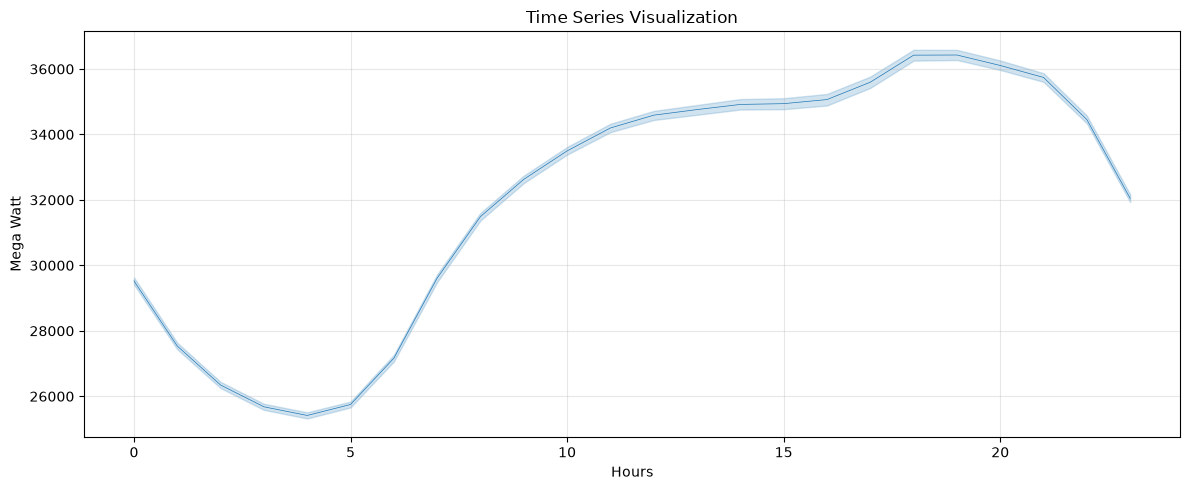

In [80]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="hour", y="PJME_MW",linewidth=0.5)
plt.title("Time Series Visualization")
plt.xlabel("Hours")
plt.ylabel("Mega Watt")
plt.grid(alpha=0.3)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

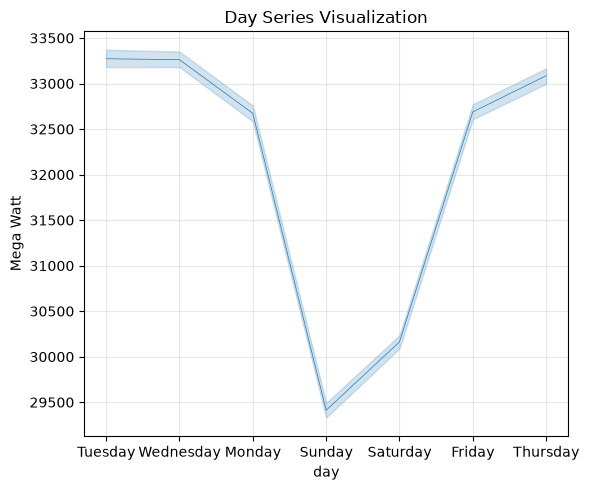

In [81]:
plt.figure(figsize=(6, 5))
sns.lineplot(data=df, x="day_name", y="PJME_MW",linewidth=0.5)
plt.title("Day Series Visualization")
plt.xlabel("day")
plt.ylabel("Mega Watt")
plt.grid(alpha=0.3)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.savefig(r'../static/images/day.png', dpi=300, bbox_inches='tight', )
plt.show()

In [82]:
#monthly

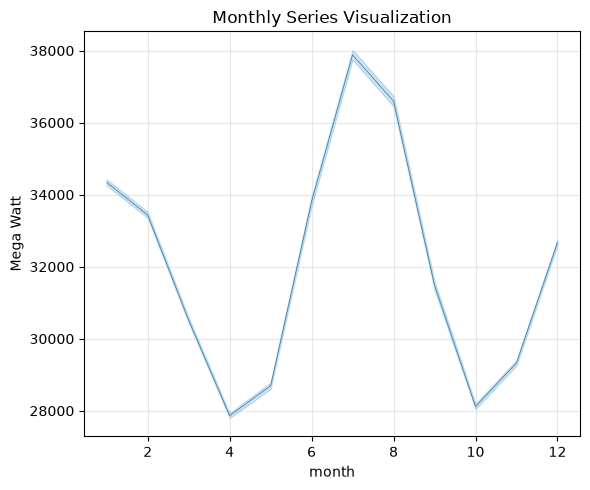

In [83]:
plt.figure(figsize=(6, 5))
sns.lineplot(data=df, x="month", y="PJME_MW",linewidth=0.5)
plt.title("Monthly Series Visualization")
plt.xlabel("month")
plt.ylabel("Mega Watt")
plt.grid(alpha=0.3)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.savefig(r'../static/images/monthly.png', dpi=300, bbox_inches='tight', )
plt.show()

In [84]:
#distribution plot

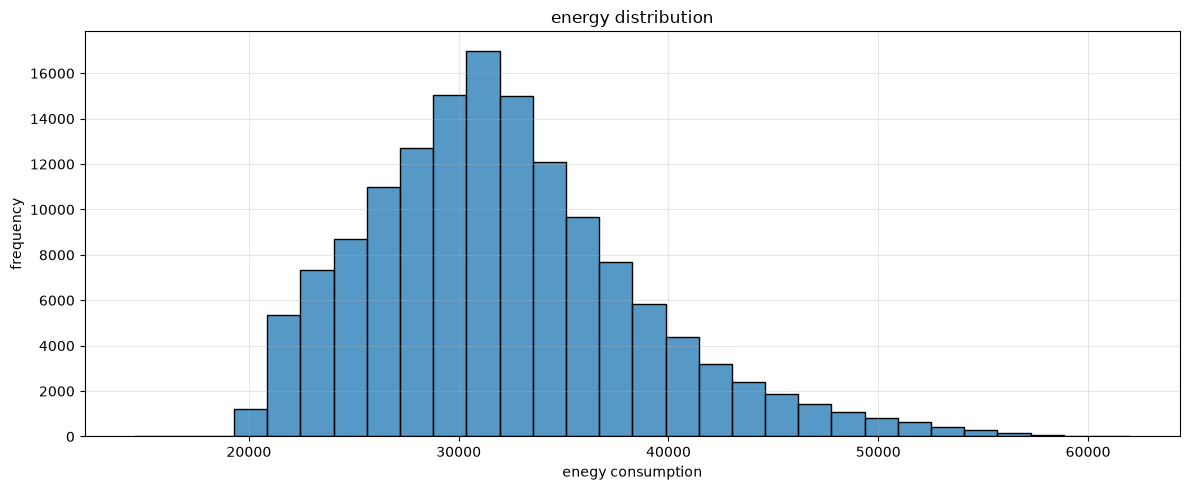

In [85]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="PJME_MW",bins=30)
plt.title("energy distribution")
plt.xlabel("enegy consumption")
plt.ylabel("frequency")
plt.grid(alpha=0.3)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

In [87]:
df['week_of_year'] = df['Datetime'].dt.isocalendar().week

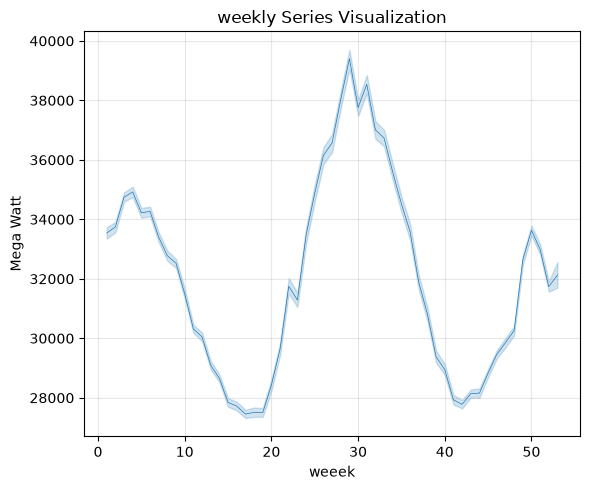

In [88]:
plt.figure(figsize=(6, 5))
sns.lineplot(data=df, x="week_of_year", y="PJME_MW",linewidth=0.5)
plt.title("weekly Series Visualization")
plt.xlabel("weeek")
plt.ylabel("Mega Watt")
plt.grid(alpha=0.3)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.savefig(r'../static/images/weekly.png', dpi=300, bbox_inches='tight', )
plt.show()

In [ ]:
df.to_csv(r'../data/cleaned/timestap_pjme.csv',index=False)